In [101]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# Credit Risk Segmentation Using Synthetic Financial Behavior Data

This project builds a two-stage credit risk scoring system that mirrors how banks identify and segment risky customers.

**Stage 1:** DuckDB SQL computes behavioral signals (utilization rate, missed payment frequency) and produces a rules-based risk tier scorecard.  
**Stage 2:** Machine learning models (Logistic Regression and Random Forest) are trained to improve on the SQL baseline using additional customer signals.

Dataset: 500,000 synthetic customers and 5,000,000 transactions, engineered with realistic financial relationships.

In [ ]:
import pandas as pd
import numpy as np
import duckdb

np.random.seed(42)
n = 500000

customer_risk = np.random.beta(2, 5, n)  # natural risk score per customer

age = np.random.randint(21, 65, n)
income_band = np.random.choice(['low', 'medium', 'high'], n, p=[0.3, 0.5, 0.2])
months_on_book = np.clip(np.random.normal(50 - 40 * customer_risk, 10, n), 1, 60).astype(int)

# Vectorized credit_limit: split customers into two risk groups and draw credit
# limits for each group in one batched call instead of looping row by row
credit_limit_options = [5000, 10000, 25000, 50000]
high_risk_mask = customer_risk > 0.4
credit_limit = np.empty(n, dtype=int)
credit_limit[high_risk_mask] = np.random.choice(
    credit_limit_options, size=high_risk_mask.sum(), p=[0.6, 0.3, 0.08, 0.02]
)
credit_limit[~high_risk_mask] = np.random.choice(
    credit_limit_options, size=(~high_risk_mask).sum(), p=[0.1, 0.2, 0.4, 0.3]
)

customers = pd.DataFrame({
    'customer_id': range(1, n+1),
    'age': age,
    'income_band': income_band,
    'months_on_book': months_on_book,
    'credit_limit': credit_limit,
})


customers['risk_score'] = customer_risk

## Data Generation

Synthetic data is generated with realistic financial relationships:
- Riskier customers have higher spend relative to their credit limit
- Riskier customers are more likely to miss payments
- Riskier customers are assigned lower credit limits by the bank
- Newer customers (fewer months on book) tend to be riskier

A `risk_score` drawn from a Beta(2,5) distribution drives all these relationships — skewed toward lower values, reflecting that most customers are low risk in reality.

In [3]:
cust_ids = np.random.randint(1, n+1, 5000000)
# Vectorized lookup: customer_id runs 1..n consecutively, so indexing directly
# into the risk_score array replaces the dict-lookup-in-a-loop
customer_risks = customers['risk_score'].values[cust_ids - 1]
missed_prob = np.clip(0.05 + 0.9 * customer_risks, 0, 0.95)
missed_payment = (np.random.random(5000000) < missed_prob).astype(int)

transactions = pd.DataFrame({
    'txn_id': range(1, 5000001),
    'customer_id': cust_ids,
    'month': np.random.randint(1, 13, 5000000),
    'spend_amount': np.abs(np.random.normal(200 + 300 * customer_risks, 150, 5000000)).round(2),
    'missed_payment': missed_payment,
    'merchant_category': np.random.choice(['retail', 'travel', 'food', 'utilities'], 5000000)
})

In [104]:
con = duckdb.connect()
con.register('customers', customers)
con.register('transactions', transactions)

## SQL Risk Scoring with DuckDB

DuckDB is used to aggregate 5M transactions to the customer level, computing two key behavioral signals:

- **Utilization rate:** average monthly spend as a proportion of credit limit (capped at 100%)
- **Missed payment frequency:** percentage of transactions where payment was missed

These are combined into a composite `raw_risk_score` and used to segment customers into four risk tiers: Low, Medium, High, and Very High Risk.

In [113]:
# Query 1
utilization = con.execute("""
    SELECT 
        customer_id,
        credit_limit,
        total_spend,
        ROUND(LEAST(monthly_spend / credit_limit, 1.0), 2) AS utilization_rate
    FROM (
        SELECT 
            c.customer_id,
            c.credit_limit,
            SUM(t.spend_amount) AS total_spend,
            SUM(t.spend_amount) / 12.0 AS monthly_spend
        FROM customers c
        JOIN transactions t ON c.customer_id = t.customer_id
        GROUP BY c.customer_id, c.credit_limit
    )
""").df()
con.register('utilization', utilization)

# Query 2
missed = con.execute("""
    SELECT
        customer_id,
        COUNT(*) AS total_txns,
        SUM(missed_payment) AS missed_payments,
        ROUND(SUM(missed_payment) * 100.0 / COUNT(*), 2) AS missed_pct
    FROM transactions
    GROUP BY customer_id
""").df()
con.register('missed', missed)

# Query 3
risk_scores = con.execute("""
    SELECT
        u.customer_id,
        u.utilization_rate,
        m.missed_pct,
        ROUND((u.utilization_rate * 0.5) + (m.missed_pct / 100 * 0.5), 4) AS raw_risk_score
    FROM utilization u
    JOIN missed m ON u.customer_id = m.customer_id
""").df()
con.register('risk_scores', risk_scores)

# Query 4
final_df = con.execute("""
    SELECT *,
        CASE 
            WHEN raw_risk_score < 0.10 THEN 'Low Risk'
            WHEN raw_risk_score < 0.20 THEN 'Medium Risk'
            WHEN raw_risk_score < 0.35 THEN 'High Risk'
            ELSE 'Very High Risk'
        END AS risk_tier
    FROM risk_scores
""").df()

In [114]:
final_df = final_df.merge(
    customers[['customer_id', 'months_on_book', 'credit_limit', 'risk_score']],
    on='customer_id'
)

## Machine Learning: Improving on the SQL Baseline

The SQL scorecard is fast and explainable but relies on hand-crafted weights. Here we train two ML models to learn the relationships from data directly.

The `raw_risk_score` from the SQL stage is included as a feature — the model's job is to improve on it using additional signals (tenure, credit limit).

**Important:** `missed_pct` is excluded from features to avoid data leakage — it is directly derived from the same process that generates the target variable, so including it would give the model an unrealistic shortcut.

Two models are compared using 5-fold cross-validation AUC.

In [115]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

features = ['utilization_rate', 'months_on_book', 'credit_limit', 'raw_risk_score']
X = final_df[features]
y = (final_df['risk_score'] > 0.4).astype(int)

models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=1000))
    ]),
    'Random Forest': Pipeline([
        ('model', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
    ])
}

for name, pipeline in models.items():
    scores = cross_val_score(pipeline, X, y, cv=5, scoring='roc_auc')
    print(f"{name}: CV AUC = {scores.mean():.4f}")

Logistic Regression: CV AUC = 0.9514
Random Forest: CV AUC = 0.9420


## Results


Logistic Regression and Random Forest both achieve CV AUC ~0.95, confirming that behavioral signals ie utilization rate, tenure, and credit limit, are strong predictors of underlying credit risk.

Logistic Regression marginally outperforms Random Forest (0.9514 vs 0.9423), suggesting the relationships between features and risk are largely linear in nature. In a production setting, this is actually preferable — Logistic Regression is faster, more interpretable, and easier to validate for regulators, which are key considerations in real credit risk environments.

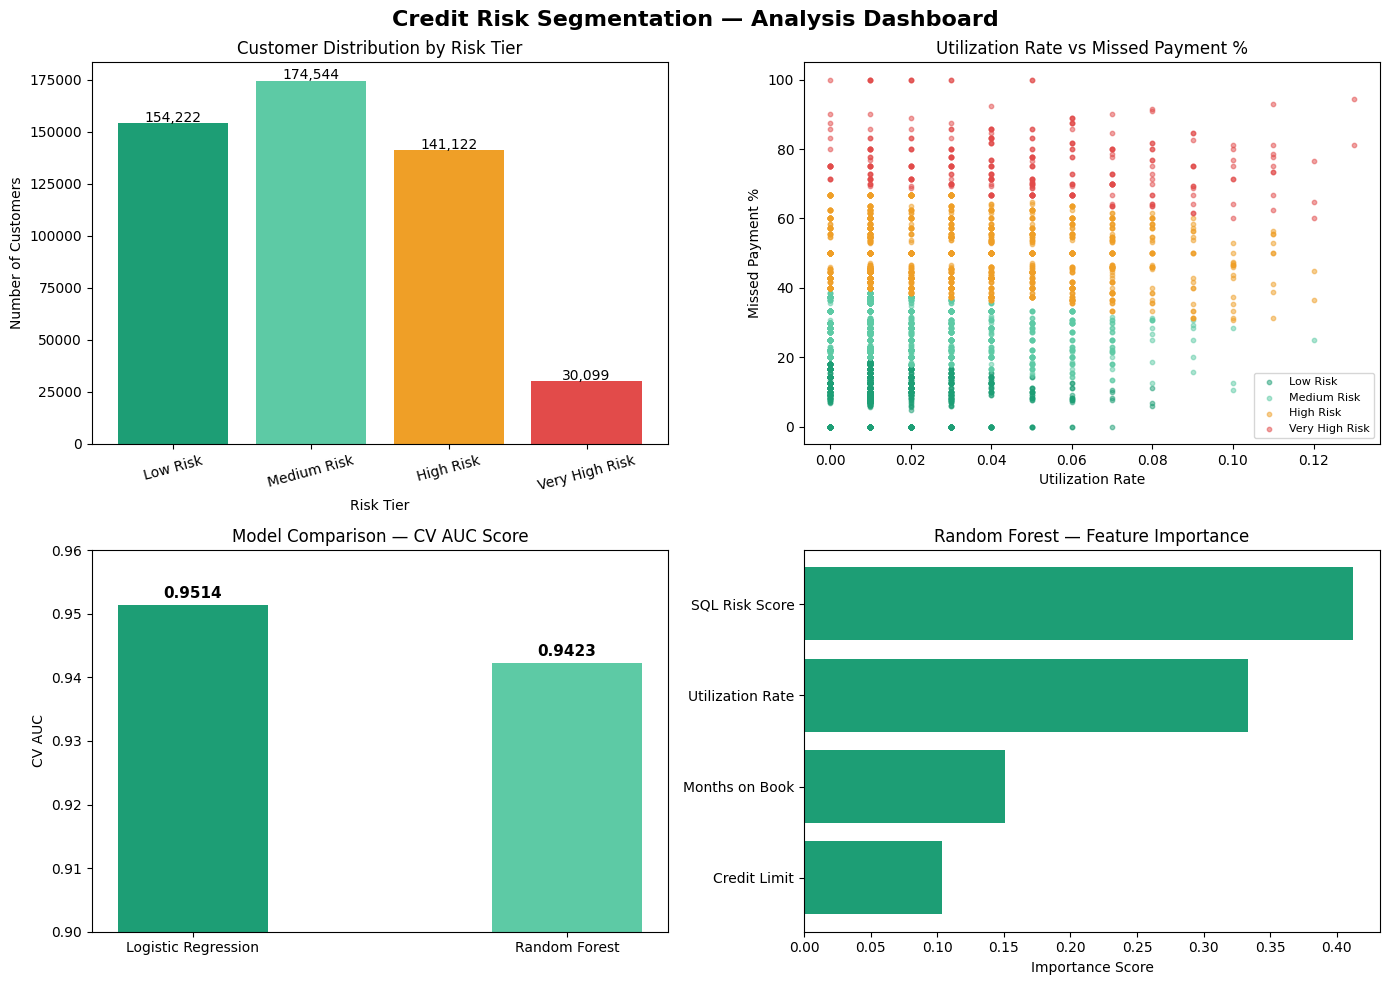

In [116]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Credit Risk Segmentation — Analysis Dashboard', fontsize=16, fontweight='bold')

# Plot 1 - Risk tier distribution
tier_counts = final_df['risk_tier'].value_counts().reindex(['Low Risk', 'Medium Risk', 'High Risk', 'Very High Risk'])
colors = ['#1D9E75', '#5DCAA5', '#EF9F27', '#E24B4A']
axes[0,0].bar(tier_counts.index, tier_counts.values, color=colors)
axes[0,0].set_title('Customer Distribution by Risk Tier')
axes[0,0].set_xlabel('Risk Tier')
axes[0,0].set_ylabel('Number of Customers')
axes[0,0].tick_params(axis='x', rotation=15)
for i, v in enumerate(tier_counts.values):
    axes[0,0].text(i, v + 500, f'{v:,}', ha='center', fontsize=10)

# Plot 2 - Utilization vs missed payments
sample = final_df.sample(5000, random_state=42)
color_map = {'Low Risk': '#1D9E75', 'Medium Risk': '#5DCAA5', 'High Risk': '#EF9F27', 'Very High Risk': '#E24B4A'}
for tier, color in color_map.items():
    mask = sample['risk_tier'] == tier
    axes[0,1].scatter(sample[mask]['utilization_rate'], sample[mask]['missed_pct'], 
                      c=color, label=tier, alpha=0.5, s=10)
axes[0,1].set_title('Utilization Rate vs Missed Payment %')
axes[0,1].set_xlabel('Utilization Rate')
axes[0,1].set_ylabel('Missed Payment %')
axes[0,1].legend(fontsize=8)

# Plot 3 - Model comparison
model_names = ['Logistic Regression', 'Random Forest']
auc_scores = [0.9514, 0.9423]
bars = axes[1,0].bar(model_names, auc_scores, color=['#1D9E75', '#5DCAA5'], width=0.4)
axes[1,0].set_title('Model Comparison — CV AUC Score')
axes[1,0].set_ylabel('CV AUC')
axes[1,0].set_ylim(0.9, 0.96)
for bar, score in zip(bars, auc_scores):
    axes[1,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001, 
                   f'{score}', ha='center', fontsize=11, fontweight='bold')

# Plot 4 - Feature importance
features = ['utilization_rate', 'months_on_book', 'credit_limit', 'raw_risk_score']
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(final_df[features], y)
importances = rf.feature_importances_
feature_names = ['Utilization Rate', 'Months on Book', 'Credit Limit', 'SQL Risk Score']
sorted_idx = importances.argsort()
axes[1,1].barh([feature_names[i] for i in sorted_idx], importances[sorted_idx], color='#1D9E75')
axes[1,1].set_title('Random Forest — Feature Importance')
axes[1,1].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('credit_risk_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

## Analysis Dashboard

### Customer Distribution by Risk Tier
The majority of customers fall into Low and Medium Risk tiers (154K and 174K respectively), with progressively fewer in High Risk (141K) and Very High Risk (30K). This reflects a realistic credit portfolio where most customers are manageable risk and a smaller segment requires closer monitoring.

### Utilization Rate vs Missed Payment %
Higher risk tiers (orange and red) concentrate at higher missed payment percentages, confirming that missed payment frequency is a strong signal of underlying credit risk. Low Risk customers (green) cluster toward lower missed payment rates across all utilization levels, validating the relationships engineered into the synthetic data.

### Model Comparison
Logistic Regression (AUC 0.9514) marginally outperforms Random Forest (AUC 0.9423), suggesting the relationships between behavioral features and credit risk are largely linear. In a real credit risk environment, Logistic Regression is actually preferable due to its interpretability and ease of regulatory validation.

### Feature Importance
The SQL Risk Score is the strongest predictor (importance 0.41), confirming the rules-based scorecard captures meaningful signal. Utilization Rate ranks second (0.33), followed by Months on Book (0.15) and Credit Limit (0.11). This aligns with real credit risk intuition — how much someone spends relative to their limit matters more than how long they have been a customer.

In [118]:
# Final output table
final_output = final_df[['customer_id', 'risk_tier', 'raw_risk_score']].copy()

pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])
pipeline_lr.fit(X, y)
final_output['model_probability'] = pipeline_lr.predict_proba(X)[:, 1]

final_output['decision'] = final_output['model_probability'].apply(
    lambda x: 'Approve' if x < 0.3 else ('Review' if x < 0.6 else 'Decline')
)

print(final_output.head(10))
print(final_output['decision'].value_counts())

   customer_id       risk_tier  raw_risk_score  model_probability decision
0       306380     Medium Risk          0.1300           0.010767  Approve
1       425795       High Risk          0.2388           0.256382  Approve
2       327904     Medium Risk          0.1866           0.446097   Review
3       163794     Medium Risk          0.1868           0.040529  Approve
4         4701       High Risk          0.2550           0.210172  Approve
5       113538       High Risk          0.2067           0.878928  Decline
6       234974  Very High Risk          0.4046           0.949782  Decline
7       175455        Low Risk          0.0676           0.290919  Approve
8       454520     Medium Risk          0.1579           0.064065  Approve
9       401646     Medium Risk          0.1479           0.013741  Approve
decision
Approve    363813
Decline     93903
Review      42271
Name: count, dtype: int64


## Credit Decisioning Output

The final stage combines the SQL risk tier and ML model probability into a 
customer-level decision — approve, review, or decline. This mirrors how 
real credit risk systems operationalize model scores into actionable decisions.